In [1]:
# ¿Cuánto tiempo se espera que permanezca un cliente de telecomunicaciones y cómo cambia esa expectativa según su tipo de contrato?

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

activity_dir = Path("..")
data_dir = activity_dir / "data"
submission_dir = activity_dir / "submission"

In [2]:
# La fuente es una muestra de IBM para una empresa ficticia; su propósito aquí es explicar censura y duración, no describir el mercado real.

customers = pd.read_csv(data_dir / "telco_customer_churn.csv.gz")
customers["tenure"] = pd.to_numeric(customers["tenure"], errors="coerce")
customers["event"] = customers["Churn"].eq("Yes")
customers = customers.dropna(subset=["tenure", "Contract"]).copy()

customers[["customerID", "tenure", "Contract", "Churn"]].head()

,customerID,tenure,Contract,Churn
0,7590-VHVEG,1,Month-to-month,No
1,5575-GNVDE,34,One year,No
2,3668-QPYBK,2,Month-to-month,Yes
3,7795-CFOCW,45,One year,No
4,9237-HQITU,2,Month-to-month,Yes


In [3]:
# Un cliente que continúa activo aporta tiempo observado, pero no una fecha de abandono: ese registro está censurado a la derecha.

summary = (
    customers.groupby("Contract", observed=True)
    .agg(
        customers=("customerID", "size"),
        churn_events=("event", "sum"),
        censored_customers=("event", lambda values: (~values).sum()),
        mean_observed_tenure_months=("tenure", "mean"),
    )
    .reset_index()
)
summary["event_rate"] = summary["churn_events"] / summary["customers"]
summary.round(2)

,Contract,customers,churn_events,censored_customers,mean_observed_tenure_months,event_rate
0,Month-to-month,3875,1655,2220,18.04,0.43
1,One year,1473,166,1307,42.04,0.11
2,Two year,1695,48,1647,56.74,0.03


In [4]:
# Kaplan–Meier actualiza la probabilidad de permanencia solo en los meses con abandonos; los clientes censurados salen del conjunto en riesgo sin contarse como eventos.

def kaplan_meier(frame):
    events = frame.groupby("tenure", observed=True).agg(
        events=("event", "sum"),
        censored=("event", lambda values: (~values).sum()),
    ).sort_index()

    at_risk = len(frame)
    survival = 1.0
    rows = [{"tenure_months": 0, "at_risk": at_risk, "events": 0, "censored": 0, "survival_probability": survival}]

    for tenure, row in events.iterrows():
        if row["events"]:
            survival *= 1 - row["events"] / at_risk
        rows.append({
            "tenure_months": int(tenure),
            "at_risk": int(at_risk),
            "events": int(row["events"]),
            "censored": int(row["censored"]),
            "survival_probability": survival,
        })
        at_risk -= int(row["events"] + row["censored"])

    return pd.DataFrame(rows)

curves = []
for contract, group in customers.groupby("Contract", observed=True):
    curve = kaplan_meier(group)
    curve["contract"] = contract
    curves.append(curve)

survival_curves = pd.concat(curves, ignore_index=True)
survival_curves.head(8)

,tenure_months,at_risk,events,censored,survival_probability,contract
0,0,3875,0,0,1.000000,Month-to-month
1,1,3875,380,224,0.901935,Month-to-month
2,2,3271,121,109,0.868571,Month-to-month
3,3,3041,94,97,0.841723,Month-to-month
4,4,2850,82,83,0.817505,Month-to-month
5,5,2685,63,65,0.798323,Month-to-month
6,6,2557,40,55,0.785835,Month-to-month
7,7,2462,50,63,0.769876,Month-to-month


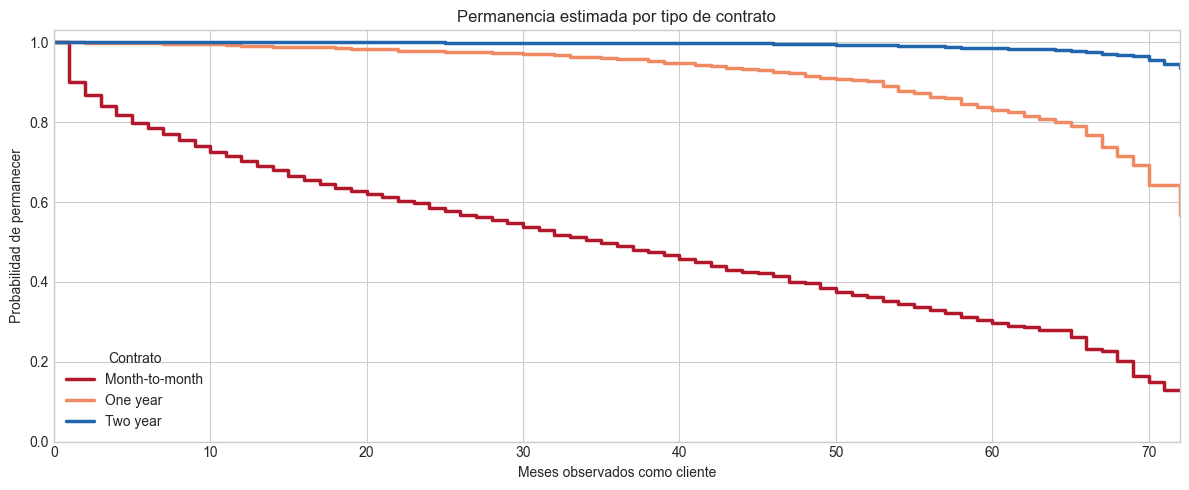

In [5]:
# Las curvas permiten ver cuándo se separa la permanencia esperada; los escalones son una consecuencia de observar abandonos por mes.

contract_order = ["Month-to-month", "One year", "Two year"]
colors = {"Month-to-month": "#b2182b", "One year": "#ef8a62", "Two year": "#2166ac"}

figure, axis = plt.subplots(figsize=(12, 5))
for contract in contract_order:
    curve = survival_curves[survival_curves["contract"] == contract]
    axis.step(
        curve["tenure_months"], curve["survival_probability"],
        where="post", linewidth=2.5, color=colors[contract], label=contract,
    )

axis.set_title("Permanencia estimada por tipo de contrato")
axis.set_xlabel("Meses observados como cliente")
axis.set_ylabel("Probabilidad de permanecer")
axis.set_xlim(0, 72)
axis.set_ylim(0, 1.03)
axis.legend(title="Contrato")
figure.tight_layout()
plt.show()

In [6]:
# La tabla transforma las curvas en una respuesta operativa acotada: permanencia estimada a 12, 24 y 36 meses, sin convertirla todavía en una intervención.

checkpoints = pd.DataFrame({"tenure_months": [12, 24, 36]})
retention_by_contract = checkpoints.copy()
for contract in contract_order:
    curve = survival_curves[survival_curves["contract"] == contract]
    retention_by_contract[contract] = [
        curve.loc[curve["tenure_months"] <= month, "survival_probability"].iloc[-1]
        for month in checkpoints["tenure_months"]
    ]

retention_by_contract.round(3)

,tenure_months,Month-to-month,One year,Two year
0,12,0.703,0.991,1.000
1,24,0.586,0.978,1.000
2,36,0.491,0.959,0.999


In [7]:
# La evidencia conserva el cálculo y sus límites: la muestra transversal no identifica una cohorte común ni demuestra que un contrato cause la permanencia.

figure.savefig(submission_dir / "survival_curves.png", dpi=150, bbox_inches="tight")
survival_curves.to_csv(submission_dir / "survival_curves.csv", index=False)
retention_by_contract.to_csv(submission_dir / "retention_by_contract.csv", index=False)

assumptions = {
    "question": "How long is a customer expected to remain, and how does estimated survival differ by contract type?",
    "outcome": "Observed tenure in months; Churn=Yes is an event and Churn=No is right-censored.",
    "method": "Kaplan–Meier survival curves by contract type.",
    "interpretation": "The curves estimate observed retention patterns; they do not establish a causal effect of contract type.",
    "limitations": [
        "IBM identifies this as sample data for a fictional telecommunications company.",
        "The data are a cross-sectional snapshot rather than a common inception cohort.",
        "The activity predicts time-to-event patterns; selecting a retention offer is a prescriptive question outside its scope.",
    ],
}
(submission_dir / "model_assumptions.json").write_text(
    json.dumps(assumptions, indent=2) + "\n"
)

summary.round(2), retention_by_contract.round(3)

(         Contract  customers  churn_events  censored_customers  \
 0  Month-to-month       3875          1655                2220   
 1        One year       1473           166                1307   
 2        Two year       1695            48                1647   
 
    mean_observed_tenure_months  event_rate  
 0                        18.04        0.43  
 1                        42.04        0.11  
 2                        56.74        0.03  ,
    tenure_months  Month-to-month  One year  Two year
 0             12           0.703     0.991     1.000
 1             24           0.586     0.978     1.000
 2             36           0.491     0.959     0.999)